# Google Search Ranking & Discoverability — Machine Learning Engineering Internship Capstone

**Ranking-signal analysis, predictive search-demand modeling, SHAP explainability, performance archetypes, and content-opportunity prioritization**



# Capstone name - Search Performance Opportunity Scoring & Content Prioritization

## Abstract

This capstone asks whether observed search-performance signals can support a defensible, forward-looking content prioritization workflow. Daily FlyRank warehouse records are aggregated to monthly client-content observations, and a temporally ordered median baseline, Random Forest, and XGBoost comparison is used to predict `log1p(next_month_impressions)` from 16 current-month search and engagement signals. XGBoost is selected using validation performance and, on the held-out April–May 2026 test period, achieves **MAE 1.0434 and RMSE 1.3843**, compared with the median baseline's **MAE 2.3938 and RMSE 2.8875**. SHAP provides model explanations, while MiniBatchKMeans groups observations into measurable performance archetypes that add descriptive context to the opportunity queue. The final output is therefore a ranked, human-reviewed content opportunity system rather than a causal claim about Google's algorithm or a guarantee that refreshing a page will improve search performance.


## 1. Question

### Research Question

Can observed search-performance and ranking signals be used to predict next-month search demand and identify content opportunities for human review?

### Selected Approach

This capstone combines the components specified in the capstone plan, adapted to the fields actually available in the FlyRank warehouse release:

1. **Ranking Signal Analysis** — supervised tree-based models use current-month ranking, traffic, and engagement signals to predict next-month search impressions.
2. **SHAP Explainability** — SHAP explains which available signals contribute most strongly to the selected model's predictions.
3. **Performance Archetype Clustering** — unsupervised clustering groups observations with similar measurable search-performance patterns.
4. **Opportunity Scoring** — model predictions and observed signals are converted into a ranked content-review queue.

### Decision Supported

The system supports an SEO/content decision: **which content observations should be reviewed first, what measurable signals support that priority, and what performance archetype provides additional context?**

### Scope and public-safe framing

The project uses public-safe aggregate outputs only. It does not expose client names, domains, private queries, credentials, or raw warehouse exports.

It does not attempt to reproduce Google's ranking algorithm, prove a causal refresh effect, or guarantee that a content change will improve search performance.


## 2. Data

### 2.1 Release and source

The analysis uses the **FlyRank internship warehouse release** available to this capstone notebook, queried from the daily content-performance Parquet tables.

**Public credit:** Built on the FlyRank ML Internship dataset.

### 2.2 Table and grain

Primary table pattern:

`fact_content_daily_performance/**/*.parquet`

The source is daily client-content performance data. The modeling dataset is aggregated to **monthly client-content observations**.

### 2.3 Date window

The available warehouse coverage is audited directly in the notebook. The modeling design uses months with a known next-month outcome and excludes the final month from supervised evaluation because a future target cannot be constructed.

### 2.4 Available signals used

The release provides measurable search and engagement signals including:

- GSC impressions and clicks
- average search position
- GA4 pageviews, sessions, users, and engagement
- traffic-source session fields
- AI-source sessions
- scroll events

### 2.5 What is excluded and why

The original plan mentions domain authority, backlink metrics, on-page signals, content freshness, content type, structure, and content length. These fields are **not available in the audited warehouse schema**, so they are not invented or proxied.

The release also does not provide query-level keyword text suitable for a public-safe keyword-level opportunity table. Therefore, this notebook does not claim to output “best archetype for [keyword]” or a keyword-level top-3 probability.

Identifiers are used only for internal aggregation and next-month joins and are excluded from model features and public-facing outputs.

### 2.6 Data-safety rule

No client names, domains, URLs, private queries, credentials, or raw exports are included in the research artifact.


In [ ]:
# Data availability audit

# We first inspect the warehouse schema before deciding which
# ranking, content, freshness, or authority features can be used.

!pip -q install duckdb pandas pyarrow

import duckdb
import pandas as pd
import numpy as np
from google.colab import userdata

# 1. Connect to FlyRank warehouse

HF_TOKEN = userdata.get("HF_TOKEN")

if not HF_TOKEN:
    raise ValueError(
        "HF_TOKEN is missing. Add your Hugging Face READ token "
        "in Colab Secrets and enable notebook access."
    )

con = duckdb.connect()

safe_token = HF_TOKEN.replace("'", "''")

con.execute(
    f"CREATE SECRET (TYPE huggingface, TOKEN '{safe_token}')"
)

REL = "hf://datasets/FlyRank/internship-warehouse"

# 2. Inspect available columns

schema_query = f"""
DESCRIBE
SELECT *
FROM read_parquet(
    '{REL}/fact_content_daily_performance/**/*.parquet',
    hive_partitioning = true
)
"""

schema_df = con.sql(schema_query).df()

print("Available warehouse fields:")
display(schema_df)

Available warehouse fields:


,column_name,column_type,null,key,default,extra
0,report_date,DATE,YES,None,None,None
1,client_hash_id,VARCHAR,YES,None,None,None
2,content_hash_id,VARCHAR,YES,None,None,None
3,client_has_gsc,BOOLEAN,YES,None,None,None
4,client_has_ga4,BOOLEAN,YES,None,None,None
5,gsc_data_available,BOOLEAN,YES,None,None,None
6,ga4_data_available,BOOLEAN,YES,None,None,None
7,gsc_impressions,BIGINT,YES,None,None,None
8,gsc_clicks,BIGINT,YES,None,None,None
9,gsc_sum_position,BIGINT,YES,None,None,None


In [ ]:
# 3. Inspect one sample row

sample_query = f"""
SELECT *
FROM read_parquet(
    '{REL}/fact_content_daily_performance/**/*.parquet',
    hive_partitioning = true
)
LIMIT 3
"""

sample_df = con.sql(sample_query).df()

print("Sample rows:")
display(sample_df)

Sample rows:


,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month
0,2025-01-27,client_9958f0a7ae1df715,content_3b70a18ea133b2bb,True,True,True,False,30,0,115,...,0,0,0,0,0,0,0,0,0,2025-01
1,2025-01-27,client_9958f0a7ae1df715,content_fe8e8155ce1d47a2,True,True,True,False,5,0,358,...,0,0,0,0,0,0,0,0,0,2025-01
2,2025-01-27,client_9958f0a7ae1df715,content_b4462a1b90640058,True,True,True,False,1,0,34,...,0,0,0,0,0,0,0,0,0,2025-01


In [ ]:
# Temporal coverage audit

coverage_query = f"""
SELECT
    month,
    COUNT(*) AS daily_rows,
    COUNT(DISTINCT client_hash_id) AS clients,
    COUNT(DISTINCT content_hash_id) AS content_items,

    SUM(
        CASE
            WHEN gsc_data_available IS TRUE THEN 1
            ELSE 0
        END
    ) AS gsc_available_rows,

    SUM(
        CASE
            WHEN ga4_data_available IS TRUE THEN 1
            ELSE 0
        END
    ) AS ga4_available_rows

FROM read_parquet(
    '{REL}/fact_content_daily_performance/**/*.parquet',
    hive_partitioning = true
)

GROUP BY month
ORDER BY month
"""

coverage_df = con.sql(coverage_query).df()

print("Monthly warehouse coverage:")
display(coverage_df)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Monthly warehouse coverage:


,month,daily_rows,clients,content_items,gsc_available_rows,ga4_available_rows
0,2025-01,1297,2,476,1297.0,0.0
1,2025-02,75985,3,5903,75985.0,0.0
2,2025-03,167859,4,10374,167859.0,0.0
3,2025-04,285114,4,13046,285114.0,0.0
4,2025-05,349923,4,14887,349923.0,0.0
5,2025-06,329201,9,16399,329201.0,0.0
6,2025-07,469794,16,27945,469794.0,0.0
7,2025-08,704962,15,37204,704962.0,0.0
8,2025-09,845813,23,53127,845813.0,0.0
9,2025-10,2165471,31,110339,1187654.0,9545.0


In [ ]:
# Confirm final warehouse date

final_coverage_query = f"""
SELECT
    MIN(report_date) AS first_date,
    MAX(report_date) AS last_date,
    MIN(month) AS first_month,
    MAX(month) AS last_month,
    COUNT(DISTINCT month) AS number_of_months
FROM read_parquet(
    '{REL}/fact_content_daily_performance/**/*.parquet',
    hive_partitioning = true
)
"""

final_coverage_df = con.sql(final_coverage_query).df()

display(final_coverage_df)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,first_date,last_date,first_month,last_month,number_of_months
0,2025-01-27,2026-06-30,2025-01,2026-06,18


In [ ]:
# Build temporal modeling dataset

import pandas as pd
import numpy as np

temporal_query = f"""
WITH monthly AS (

    SELECT
        client_hash_id,
        content_hash_id,
        month,

        -- GSC search signals
        SUM(gsc_impressions) AS impressions,
        SUM(gsc_clicks) AS clicks,
        SUM(gsc_sum_position) AS sum_position,

        -- GA4 engagement signals
        SUM(ga4_pageviews) AS pageviews,
        SUM(ga4_sessions) AS sessions,
        SUM(ga4_users) AS users,
        SUM(ga4_engaged_sessions) AS engaged_sessions,
        SUM(ga4_total_engagement_sec) AS engagement_seconds,

        -- Traffic sources
        SUM(sessions_organic) AS sessions_organic,
        SUM(sessions_direct) AS sessions_direct,
        SUM(sessions_referral) AS sessions_referral,
        SUM(sessions_social) AS sessions_social,
        SUM(sessions_paid) AS sessions_paid,
        SUM(sessions_ai) AS sessions_ai,

        -- Engagement
        SUM(scroll_events) AS scroll_events,

        -- Availability flags
        BOOL_OR(gsc_data_available) AS has_gsc,
        BOOL_OR(ga4_data_available) AS has_ga4

    FROM read_parquet(
        '{REL}/fact_content_daily_performance/**/*.parquet',
        hive_partitioning = true
    )

    GROUP BY
        client_hash_id,
        content_hash_id,
        month
),

features AS (

    SELECT
        *,

        -- Monthly CTR
        CASE
            WHEN impressions > 0
            THEN clicks * 1.0 / impressions
            ELSE NULL
        END AS ctr,

        -- Weighted average position
        CASE
            WHEN impressions > 0
            THEN sum_position * 1.0 / impressions
            ELSE NULL
        END AS avg_position

    FROM monthly
),

paired AS (

    SELECT
        current.*,

        next_month.impressions AS next_impressions,
        next_month.clicks AS next_clicks,
        next_month.avg_position AS next_avg_position

    FROM features AS current

    LEFT JOIN features AS next_month

        ON current.client_hash_id = next_month.client_hash_id
        AND current.content_hash_id = next_month.content_hash_id

        AND CAST(
            strptime(current.month, '%Y-%m') + INTERVAL '1 month'
            AS DATE
        )
        =
        CAST(
            strptime(next_month.month, '%Y-%m')
            AS DATE
        )
)

SELECT
    *,

    -- Future impression trend
    CASE
        WHEN impressions > 0
             AND next_impressions IS NOT NULL
        THEN
            (next_impressions - impressions) * 1.0
            / impressions
        ELSE NULL
    END AS future_trend_pct

FROM paired

WHERE
    has_gsc = TRUE
    AND impressions > 0
"""

model_df = con.sql(temporal_query).df()

print("Temporal modeling dataset:")
print(f"Rows: {len(model_df):,}")
print(f"Columns: {len(model_df.columns)}")
display(model_df.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Temporal modeling dataset:
Rows: 1,546,456
Columns: 26


,client_hash_id,content_hash_id,month,impressions,clicks,sum_position,pageviews,sessions,users,engaged_sessions,...,sessions_ai,scroll_events,has_gsc,has_ga4,ctr,avg_position,next_impressions,next_clicks,next_avg_position,future_trend_pct
0,client_9958f0a7ae1df715,content_61cb637b1e493b91,2025-01,87.0,1.0,1235.0,0.0,0.0,0.0,0.0,...,0.0,0.0,True,False,0.011494,14.195402,847.0,14.0,11.066116,8.735632
1,client_9958f0a7ae1df715,content_e79531cf26443659,2025-01,35.0,0.0,309.0,0.0,0.0,0.0,0.0,...,0.0,0.0,True,False,0.000000,8.828571,237.0,6.0,8.886076,5.771429
2,client_9958f0a7ae1df715,content_3d9b660fe6946d8a,2025-01,52.0,0.0,509.0,0.0,0.0,0.0,0.0,...,0.0,0.0,True,False,0.000000,9.788462,174.0,0.0,11.534483,2.346154
3,client_9958f0a7ae1df715,content_0642dc7f62d4f780,2025-01,53.0,4.0,861.0,0.0,0.0,0.0,0.0,...,0.0,0.0,True,False,0.075472,16.245283,346.0,30.0,11.020231,5.528302
4,client_9958f0a7ae1df715,content_579061061abdf187,2025-01,12.0,0.0,76.0,0.0,0.0,0.0,0.0,...,0.0,0.0,True,False,0.000000,6.333333,105.0,3.0,8.895238,7.750000


In [ ]:
# Leakage and target audit

# 1. Target coverage

print("TARGET COVERAGE")
print("-" * 40)

target_total = len(model_df)
target_available = model_df["future_trend_pct"].notna().sum()
target_missing = model_df["future_trend_pct"].isna().sum()

print(f"Total rows:        {target_total:,}")
print(f"Target available:  {target_available:,}")
print(f"Target missing:    {target_missing:,}")

# 2. Check for impossible / invalid values

print("\nINVALID VALUE CHECK")
print("-" * 40)

numeric_cols = [
    "impressions",
    "clicks",
    "sum_position",
    "ctr",
    "avg_position",
    "next_impressions",
    "next_clicks",
    "next_avg_position",
    "future_trend_pct"
]

for col in numeric_cols:
    if col in model_df.columns:
        invalid = np.isinf(model_df[col].fillna(0)).sum()
        print(f"{col:22s}: {invalid:,} infinite values")

# 3. Check feature / target relationships

print("\nTARGET SUMMARY")
print("-" * 40)

display(
    model_df["future_trend_pct"]
    .describe(
        percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    )
    .to_frame()
)

# 4. Explicit leakage check

feature_candidates = [
    "impressions",
    "clicks",
    "sum_position",
    "pageviews",
    "sessions",
    "users",
    "engaged_sessions",
    "engagement_seconds",
    "sessions_organic",
    "sessions_direct",
    "sessions_referral",
    "sessions_social",
    "sessions_paid",
    "sessions_ai",
    "scroll_events",
    "ctr",
    "avg_position"
]

leakage_columns = [
    "next_impressions",
    "next_clicks",
    "next_avg_position",
    "future_trend_pct"
]

print("\nFEATURE / LEAKAGE AUDIT")
print("-" * 40)

print("Candidate model features:")
print(feature_candidates)

print("\nColumns explicitly excluded from model features:")
print(leakage_columns)

TARGET COVERAGE
----------------------------------------
Total rows:        1,546,456
Target available:  1,316,498
Target missing:    229,958

INVALID VALUE CHECK
----------------------------------------
impressions           : 0 infinite values
clicks                : 0 infinite values
sum_position          : 0 infinite values
ctr                   : 0 infinite values
avg_position          : 0 infinite values
next_impressions      : 0 infinite values
next_clicks           : 0 infinite values
next_avg_position     : 0 infinite values
future_trend_pct      : 0 infinite values

TARGET SUMMARY
----------------------------------------


,future_trend_pct
count,1.316498e+06
mean,2.093078e+00
std,4.683583e+01
min,-1.000000e+00
1%,-1.000000e+00
5%,-1.000000e+00
25%,-5.929176e-01
50%,-7.505178e-02
75%,6.628766e-01
95%,5.355336e+00



FEATURE / LEAKAGE AUDIT
----------------------------------------
Candidate model features:
['impressions', 'clicks', 'sum_position', 'pageviews', 'sessions', 'users', 'engaged_sessions', 'engagement_seconds', 'sessions_organic', 'sessions_direct', 'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai', 'scroll_events', 'ctr', 'avg_position']

Columns explicitly excluded from model features:
['next_impressions', 'next_clicks', 'next_avg_position', 'future_trend_pct']


In [ ]:
# Target coverage and stability by month

monthly_target_audit = (
    model_df
    .groupby("month")
    .agg(
        rows=("content_hash_id", "size"),
        target_available=("future_trend_pct", "count"),
        median_impressions=("impressions", "median"),
        median_future_trend=("future_trend_pct", "median"),
        p95_future_trend=(
            "future_trend_pct",
            lambda x: x.quantile(0.95)
        )
    )
    .reset_index()
)

monthly_target_audit["target_coverage_pct"] = (
    monthly_target_audit["target_available"]
    / monthly_target_audit["rows"]
    * 100
)

display(monthly_target_audit)

,month,rows,target_available,median_impressions,median_future_trend,p95_future_trend,target_coverage_pct
0,2025-01,476,327,5.0,2.727273,20.948214,68.697479
1,2025-02,5903,4885,93.0,1.053356,6.439588,82.754532
2,2025-03,10374,10060,84.0,1.063942,23.142857,96.973202
3,2025-04,13046,12616,182.0,0.413969,5.643908,96.703971
4,2025-05,14887,13948,227.0,-0.083333,1.613843,93.692483
5,2025-06,16399,14939,169.0,0.000000,4.800000,91.097018
6,2025-07,27945,25884,95.0,0.252279,14.312143,92.624799
7,2025-08,37204,33891,108.0,-0.135447,6.500000,91.095044
8,2025-09,53127,50552,76.0,0.301755,10.333333,95.153124
9,2025-10,64906,64552,66.0,0.250000,7.576786,99.454596


## 3. Methodology

### 3.1 Modeling Objective

The capstone implements a **ranking-signal analysis and content-opportunity prioritization system**. The supervised model uses signals observed in the current month to estimate **next-month Google Search impressions** for a client-content observation. This prediction is used as a directional signal for prioritization, not as a reconstruction of Google's ranking algorithm.

**Important scope alignment with the original capstone plan:** the available warehouse release does not contain query-level keyword text, a page-level SERP rank target, domain-authority values, page text, content length, explicit content-type labels, or freshness dates. It does contain `gsc_avg_position` as an observed aggregate search-position signal. Therefore, this implementation does **not** invent a keyword-level ranking target or unavailable content attributes. Instead, it uses the available ranking/traffic/engagement signals to predict next-month search demand and build a public-safe content review queue.

### 3.2 Data Aggregation and Feature Construction

Daily records from the FlyRank warehouse are aggregated to the **monthly client-content level** using `client_hash_id` and `content_hash_id` only for internal grouping and temporal joins.

The predictive feature set contains 16 current-month signals:

1. GSC impressions
2. GSC clicks
3. CTR
4. average search position
5. GA4 pageviews
6. GA4 sessions
7. GA4 users
8. GA4 engaged sessions
9. total engagement time
10. organic sessions
11. direct sessions
12. referral sessions
13. social sessions
14. paid sessions
15. AI sessions
16. scroll events

Identifiers are excluded from the feature matrix. No client names, domains, private queries, credentials, or raw exports are used in the notebook output.

The release does **not** provide reliable page text, content type, content length, backlink metrics, domain authority, or explicit freshness dates. Those fields are therefore excluded rather than approximated.

### 3.3 Temporal Target Construction and Leakage Controls

For each current-month client-content observation, the next month's observation is joined on the same client and content identifiers. The prediction target is:

`log1p(next_month_impressions)`

The log transformation reduces the influence of extreme impression counts while preserving the direction of future search demand.

The final month is excluded because it cannot form a next-month target.

Leakage controls include:

- current-month features only for predicting the next-month outcome;
- identifiers used only for grouping and temporal joins, never as predictors;
- median imputation fitted on training data only;
- no fitting of the supervised models on validation or test observations;
- clustering scaler fitted on training data only;
- validation used for model selection;
- the test period retained as the final held-out evaluation.

### 3.4 Temporal Validation Design

The notebook uses a chronological train/validation/test design with **no month overlap**:

| Split | Period | Purpose |
|---|---|---|
| Training | January–December 2025 | Fit models and preprocessing |
| Validation | January–March 2026 | Select the supervised model |
| Test | April–May 2026 | One-time held-out evaluation |
| Excluded | June 2026 | No next-month target available |

This design is preferred over a random split because search-performance observations are time-dependent and the goal is forward-looking prioritization.

### 3.5 Baseline and Random Forest / XGBoost Comparison

A **training-set median baseline** provides the simple reference point.

Two supervised tree-based regressors are compared using the same feature matrix, target, and temporal splits:

**Random Forest**
- `n_estimators=150`
- `max_depth=18`
- `min_samples_leaf=10`
- `max_features="sqrt"`
- `random_state=42`

**XGBoost**
- `n_estimators=500`
- `max_depth=8`
- `learning_rate=0.05`
- `subsample=0.8`
- `colsample_bytree=0.8`
- squared-error regression objective
- `random_state=42`

Primary metrics are **MAE** and **RMSE** on the `log1p(next_month_impressions)` scale.

The final supervised model is selected **using validation performance only**. The test period is not used for model selection.

### 3.6 SHAP Explainability

SHAP is used to explain the validation-selected tree model and complement ordinary model feature importance.

A fixed reproducible sample of up to **1,500 held-out test observations** is passed through a SHAP explainer. The notebook reports:

- global mean absolute SHAP contribution by feature;
- a paper-ready feature-contribution chart;
- the model and number of observations explained.

SHAP values are interpreted as **predictive explanations**, not causal effects. Impressions, clicks, and CTR are mathematically related signals, so high SHAP importance does not mean that independently changing one signal will cause future search growth.

### 3.7 Performance Archetype Clustering

The unsupervised layer implements the capstone plan's **content-archetype idea**, but it is named **Performance Archetype Clustering** because the warehouse does not contain page text or explicit content-type metadata.

The clustering pipeline:

1. standardizes the 16 measurable performance/engagement features using training data only;
2. compares `k=2` through `k=6`;
3. evaluates candidate `k` values using silhouette score on a reproducible training sample;
4. fits `MiniBatchKMeans` using the selected `k` on all training observations;
5. assigns the held-out test observations to the learned archetypes;
6. profiles each archetype using measurable signals;
7. provides a PCA visualization of the resulting performance patterns.

The resulting labels are intentionally descriptive, such as **Performance Archetype 1**, rather than claims such as “article,” “how-to,” “product,” or “news,” because those semantic labels are not present in the release.

### 3.8 Error Analysis

The selected model is evaluated on the untouched test period. Error analysis examines:

- overall MAE and RMSE;
- absolute error by current-month impression-volume band;
- whether low-visibility observations are systematically harder to predict.

This step is used to communicate where the model is less reliable and to prevent the opportunity queue from being interpreted without context.

### 3.9 Opportunity Scoring

The application layer converts model predictions and observed signals into a **human-review opportunity score**.

The score combines normalized percentile signals:

- **30% visibility** — current-month impressions;
- **20% CTR opportunity** — inverse CTR percentile;
- **20% position opportunity** — average-position percentile;
- **30% future-demand score** — predicted next-month impressions.

The output is a ranked queue with:

- priority rank;
- current search-performance signals;
- predicted next-month impressions;
- opportunity score;
- performance archetype context;
- review-oriented action guidance.

The score is a **decision-support prioritization mechanism**, not a probability of a guaranteed SEO outcome.

### 3.10 Reproducible Application Architecture

The implemented analytical architecture follows the capstone plan:

**FlyRank data layer → feature engineering → ML layer → application/prioritization layer**

- **ML layer:** XGBoost / Random Forest supervised prediction + SHAP explainability + KMeans-style performance archetypes.
- **Application layer:** opportunity scorer + ranked prioritization queue.
- **Research artifact:** notebook outputs and paper-ready charts.

The planned Streamlit interface is treated as an application-layer extension of this notebook. The notebook itself is the reproducible research artifact submitted with the capstone.


## 4. Results



In [ ]:
# Temporal Train / Validation / Test Split

# Keep only observations with a known next-month outcome.
model_ready_df = model_df[
    model_df["future_trend_pct"].notna()
].copy()

# 1. Define chronological periods

train_months = [
    "2025-01", "2025-02", "2025-03", "2025-04",
    "2025-05", "2025-06", "2025-07", "2025-08",
    "2025-09", "2025-10", "2025-11", "2025-12"
]

validation_months = [
    "2026-01", "2026-02", "2026-03"
]

test_months = [
    "2026-04", "2026-05"
]

# 2. Create splits

train_df = model_ready_df[
    model_ready_df["month"].isin(train_months)
].copy()

validation_df = model_ready_df[
    model_ready_df["month"].isin(validation_months)
].copy()

test_df = model_ready_df[
    model_ready_df["month"].isin(test_months)
].copy()

# 3. Display split sizes

print("TEMPORAL DATA SPLIT")
print("=" * 50)

print(f"Train:      {len(train_df):,} rows")
print(f"Validation: {len(validation_df):,} rows")
print(f"Test:       {len(test_df):,} rows")

print("\nTrain period:")
print(f"{train_df['month'].min()} → {train_df['month'].max()}")

print("\nValidation period:")
print(f"{validation_df['month'].min()} → {validation_df['month'].max()}")

print("\nTest period:")
print(f"{test_df['month'].min()} → {test_df['month'].max()}")

TEMPORAL DATA SPLIT
Train:      440,304 rows
Validation: 443,560 rows
Test:       432,634 rows

Train period:
2025-01 → 2025-12

Validation period:
2026-01 → 2026-03

Test period:
2026-04 → 2026-05


In [ ]:
# Verify that the temporal split contains no overlapping months

print("\nMONTH OVERLAP CHECK")
print("=" * 50)

train_set = set(train_df["month"].unique())
validation_set = set(validation_df["month"].unique())
test_set = set(test_df["month"].unique())

print("Train ∩ Validation:", train_set & validation_set)
print("Train ∩ Test:", train_set & test_set)
print("Validation ∩ Test:", validation_set & test_set)


MONTH OVERLAP CHECK
Train ∩ Validation: set()
Train ∩ Test: set()
Validation ∩ Test: set()


In [ ]:
# Feature matrix and target

from sklearn.impute import SimpleImputer

# 1. Define model features

feature_cols = [
    "impressions",
    "clicks",
    "ctr",
    "avg_position",
    "pageviews",
    "sessions",
    "users",
    "engaged_sessions",
    "engagement_seconds",
    "sessions_organic",
    "sessions_direct",
    "sessions_referral",
    "sessions_social",
    "sessions_paid",
    "sessions_ai",
    "scroll_events"
]

target_col = "next_impressions"

# 2. Build X and y

X_train = train_df[feature_cols].copy()
X_validation = validation_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()

y_train = np.log1p(train_df[target_col])
y_validation = np.log1p(validation_df[target_col])
y_test = np.log1p(test_df[target_col])

# 3. Handle missing feature values

imputer = SimpleImputer(strategy="median")

X_train = imputer.fit_transform(X_train)
X_validation = imputer.transform(X_validation)
X_test = imputer.transform(X_test)

# 4. Confirm dimensions

print("FEATURE MATRIX")
print("=" * 50)

print(f"Number of features: {len(feature_cols)}")
print(f"Training X:         {X_train.shape}")
print(f"Validation X:       {X_validation.shape}")
print(f"Test X:             {X_test.shape}")

print("\nTarget:")
print(f"Training y:         {y_train.shape}")
print(f"Validation y:       {y_validation.shape}")
print(f"Test y:             {y_test.shape}")

print("\nFeatures:")
for i, feature in enumerate(feature_cols, 1):
    print(f"{i:02d}. {feature}")

FEATURE MATRIX
Number of features: 16
Training X:         (440304, 16)
Validation X:       (443560, 16)
Test X:             (432634, 16)

Target:
Training y:         (440304,)
Validation y:       (443560,)
Test y:             (432634,)

Features:
01. impressions
02. clicks
03. ctr
04. avg_position
05. pageviews
06. sessions
07. users
08. engaged_sessions
09. engagement_seconds
10. sessions_organic
11. sessions_direct
12. sessions_referral
13. sessions_social
14. sessions_paid
15. sessions_ai
16. scroll_events


In [ ]:
# Median baseline

from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Baseline prediction

baseline_value = np.median(y_train)

baseline_val_pred = np.full(
    len(y_validation),
    baseline_value
)

baseline_test_pred = np.full(
    len(y_test),
    baseline_value
)

# 2. Evaluate baseline

baseline_val_mae = mean_absolute_error(
    y_validation,
    baseline_val_pred
)

baseline_val_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        baseline_val_pred
    )
)

baseline_test_mae = mean_absolute_error(
    y_test,
    baseline_test_pred
)

baseline_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_test_pred
    )
)

# 3. Display results

print("BASELINE RESULTS")
print("=" * 50)

print(f"Baseline target value: {baseline_value:.4f}")

print("\nValidation:")
print(f"MAE:  {baseline_val_mae:.4f}")
print(f"RMSE: {baseline_val_rmse:.4f}")

print("\nTest:")
print(f"MAE:  {baseline_test_mae:.4f}")
print(f"RMSE: {baseline_test_rmse:.4f}")

BASELINE RESULTS
Baseline target value: 4.9053

Validation:
MAE:  2.2666
RMSE: 2.7239

Test:
MAE:  2.3938
RMSE: 2.8875


In [ ]:
# Random Forest model

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Train Random Forest

rf_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=18,
    min_samples_leaf=10,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

# 2. Validation prediction

rf_val_pred = rf_model.predict(X_validation)

rf_val_mae = mean_absolute_error(
    y_validation,
    rf_val_pred
)

rf_val_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        rf_val_pred
    )
)

print("RANDOM FOREST — VALIDATION")
print("=" * 50)
print(f"MAE:  {rf_val_mae:.4f}")
print(f"RMSE: {rf_val_rmse:.4f}")

RANDOM FOREST — VALIDATION
MAE:  0.8426
RMSE: 1.1637


In [ ]:
# Random Forest test evaluation

rf_test_pred = rf_model.predict(X_test)

rf_test_mae = mean_absolute_error(
    y_test,
    rf_test_pred
)

rf_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_test_pred
    )
)

print("RANDOM FOREST — TEST")
print("=" * 50)

print(f"MAE:  {rf_test_mae:.4f}")
print(f"RMSE: {rf_test_rmse:.4f}")

# Compare against baseline

mae_improvement = (
    (baseline_test_mae - rf_test_mae)
    / baseline_test_mae
    * 100
)

rmse_improvement = (
    (baseline_test_rmse - rf_test_rmse)
    / baseline_test_rmse
    * 100
)

print("\nIMPROVEMENT VS BASELINE")
print("=" * 50)

print(f"MAE improvement:  {mae_improvement:.2f}%")
print(f"RMSE improvement: {rmse_improvement:.2f}%")

RANDOM FOREST — TEST
MAE:  1.0266
RMSE: 1.3661

IMPROVEMENT VS BASELINE
MAE improvement:  57.11%
RMSE improvement: 52.69%


In [ ]:
# Random Forest feature importance

feature_importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

feature_importance_df["importance_pct"] = (
    feature_importance_df["importance"] * 100
)

display(feature_importance_df)

,feature,importance,importance_pct
0,impressions,5.822712e-01,58.227122
1,ctr,1.845036e-01,18.450356
2,clicks,1.615276e-01,16.152758
3,avg_position,3.408216e-02,3.408216
4,sessions_organic,1.510121e-02,1.510121
5,pageviews,1.053111e-02,1.053111
6,users,4.194011e-03,0.419401
7,engagement_seconds,2.552918e-03,0.255292
8,sessions,2.492194e-03,0.249219
9,scroll_events,1.265600e-03,0.126560


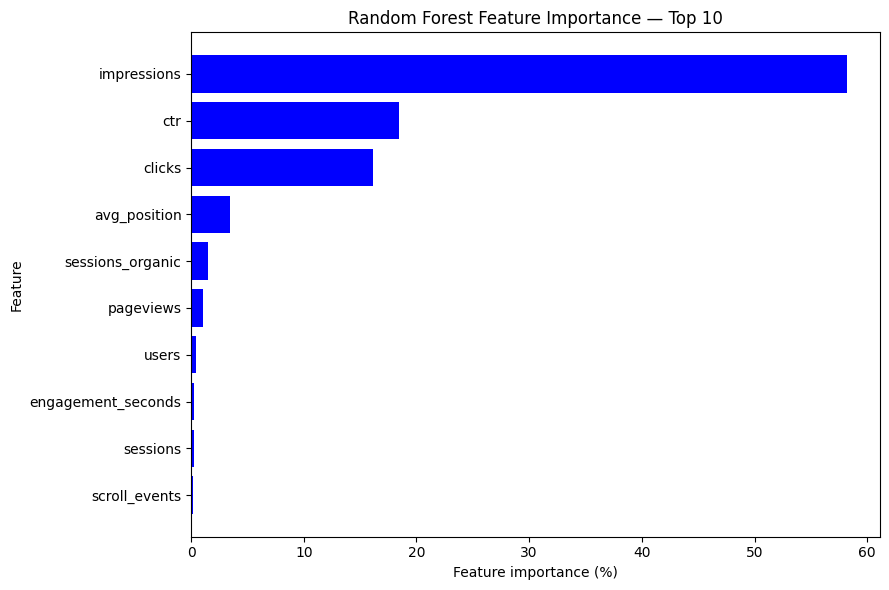

In [ ]:
# Feature importance chart

import matplotlib.pyplot as plt

top_features = feature_importance_df.head(10).sort_values(
    "importance_pct"
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["feature"],
    top_features["importance_pct"],
    color="blue"
)

plt.xlabel("Feature importance (%)")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance — Top 10")

plt.tight_layout()
plt.show()

In [ ]:
# XGBoost model

!pip -q install xgboost

from xgboost import XGBRegressor

# 1. Train XGBoost

xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    eval_metric="mae",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_validation, y_validation)],
    verbose=False
)

# 2. Validation prediction

xgb_val_pred = xgb_model.predict(X_validation)

xgb_val_mae = mean_absolute_error(
    y_validation,
    xgb_val_pred
)

xgb_val_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        xgb_val_pred
    )
)

print("XGBOOST — VALIDATION")
print("=" * 50)

print(f"MAE:  {xgb_val_mae:.4f}")
print(f"RMSE: {xgb_val_rmse:.4f}")

XGBOOST — VALIDATION
MAE:  0.8393
RMSE: 1.1650


In [ ]:
# XGBoost test evaluation

xgb_test_pred = xgb_model.predict(X_test)

xgb_test_mae = mean_absolute_error(
    y_test,
    xgb_test_pred
)

xgb_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_test_pred
    )
)

print("XGBOOST — TEST")
print("=" * 50)

print(f"MAE:  {xgb_test_mae:.4f}")
print(f"RMSE: {xgb_test_rmse:.4f}")

# Compare against baseline

xgb_mae_improvement = (
    (baseline_test_mae - xgb_test_mae)
    / baseline_test_mae
    * 100
)

xgb_rmse_improvement = (
    (baseline_test_rmse - xgb_test_rmse)
    / baseline_test_rmse
    * 100
)

print("\nIMPROVEMENT VS BASELINE")
print("=" * 50)

print(f"MAE improvement:  {xgb_mae_improvement:.2f}%")
print(f"RMSE improvement: {xgb_rmse_improvement:.2f}%")

XGBOOST — TEST
MAE:  1.0436
RMSE: 1.3841

IMPROVEMENT VS BASELINE
MAE improvement:  56.40%
RMSE improvement: 52.07%


FINAL MODEL SELECTION
Selected by validation MAE: XGBoost
Validation MAE:  0.8393
Validation RMSE: 1.1650

XGBOOST FEATURE IMPORTANCE


,feature,importance_pct
0,impressions,64.594002
1,clicks,25.591999
2,ctr,3.363000
3,avg_position,2.022000
4,scroll_events,0.811000
5,sessions_organic,0.695000
6,sessions,0.414000
7,pageviews,0.376000
8,engagement_seconds,0.349000
9,users,0.332000


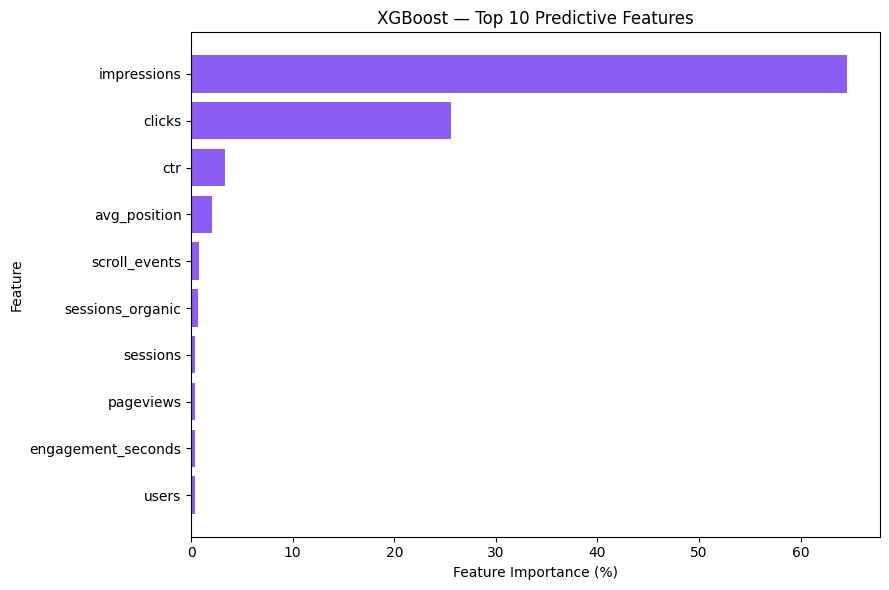

In [ ]:
# Final-model Explainability
# Feature importance for the model selected using validation performance.

import pandas as pd
import matplotlib.pyplot as plt

model_candidates = {
    "Random Forest": (rf_val_mae, rf_val_rmse, rf_model),
    "XGBoost": (xgb_val_mae, xgb_val_rmse, xgb_model)
}

final_model_name = min(
    model_candidates,
    key=lambda name: (model_candidates[name][0], model_candidates[name][1])
)
final_model = model_candidates[final_model_name][2]

print("FINAL MODEL SELECTION")
print("=" * 50)
print(f"Selected by validation MAE: {final_model_name}")
print(f"Validation MAE:  {model_candidates[final_model_name][0]:.4f}")
print(f"Validation RMSE: {model_candidates[final_model_name][1]:.4f}")

final_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": final_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

final_importance["importance_pct"] = final_importance["importance"] * 100

print(f"\n{final_model_name.upper()} FEATURE IMPORTANCE")
print("=" * 50)
display(final_importance[["feature", "importance_pct"]].round(3))

top_features = final_importance.head(10).sort_values("importance_pct")

plt.figure(figsize=(9, 6))
plt.barh(
    top_features["feature"],
    top_features["importance_pct"],
    color="#8B5CF6"
)
plt.xlabel("Feature Importance (%)")
plt.ylabel("Feature")
plt.title(f"{final_model_name} — Top 10 Predictive Features")
plt.tight_layout()
plt.show()


SHAP GLOBAL EXPLAINABILITY
Model explained: XGBoost
Observations explained: 1,500


,feature,mean_abs_shap
0,impressions,1.7386
1,clicks,0.3203
2,ctr,0.1134
3,avg_position,0.1112
4,sessions,0.0855
5,pageviews,0.0833
6,scroll_events,0.0738
7,sessions_organic,0.0552
8,engagement_seconds,0.0367
9,sessions_direct,0.0221


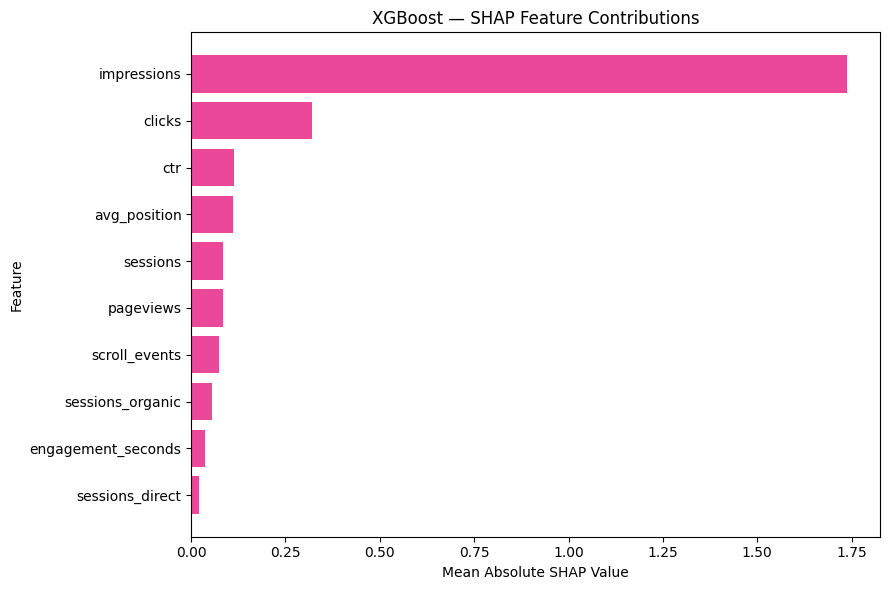

In [ ]:
# SHAP Explainability
# Explain the validation-selected final model on a fixed sample of the held-out test set.

try:
    import shap
except ImportError:
    !pip -q install shap
    import shap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

shap_sample_size = min(1500, len(X_test))
shap_rng = np.random.default_rng(42)
shap_indices = shap_rng.choice(
    len(X_test),
    size=shap_sample_size,
    replace=False
)

X_shap = X_test[shap_indices]

explainer = shap.Explainer(final_model)
shap_explanation = explainer(X_shap)
shap_values = shap_explanation.values

shap_importance = pd.DataFrame({
    "feature": feature_cols,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values(
    "mean_abs_shap",
    ascending=False
).reset_index(drop=True)

print("SHAP GLOBAL EXPLAINABILITY")
print("=" * 60)
print(f"Model explained: {final_model_name}")
print(f"Observations explained: {shap_sample_size:,}")
display(shap_importance.round(4))

top_shap = shap_importance.head(10).sort_values("mean_abs_shap")

plt.figure(figsize=(9, 6))
plt.barh(
    top_shap["feature"],
    top_shap["mean_abs_shap"],
    color="#EC4899"
)
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title(f"{final_model_name} — SHAP Feature Contributions")
plt.tight_layout()
plt.show()


CLUSTER COUNT SELECTION


,k,silhouette_score
0,2,0.4554
1,3,0.2987
2,4,0.3289
3,5,0.4546
4,6,0.2736


Selected k: 2

TEST-SET ARCHETYPE COUNTS


,archetype,observations
0,Performance Archetype 1,343520
1,Performance Archetype 2,89114


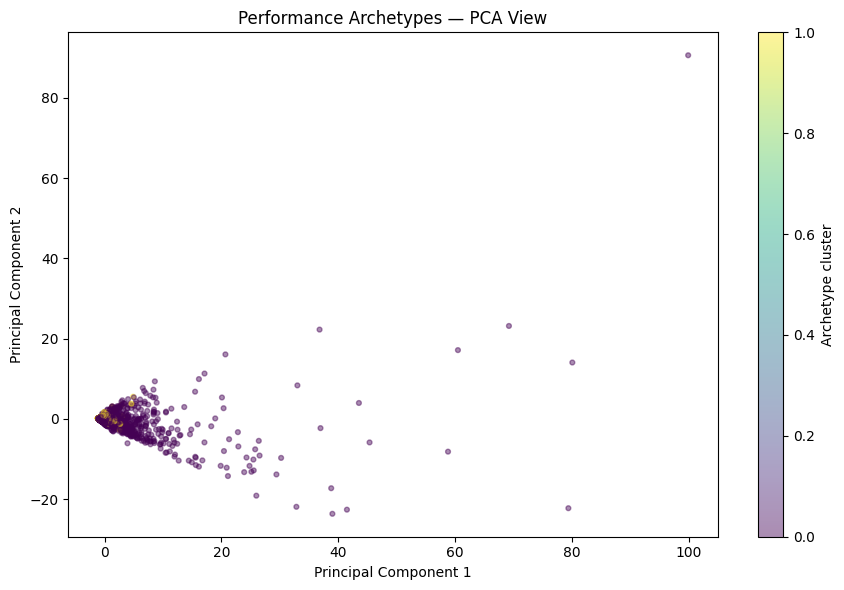

In [ ]:
# Performance Archetype Clustering
# Discover groups of observations with similar measurable search-performance patterns.

from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Scale using training data only so the clustering setup respects the temporal design.
cluster_scaler = StandardScaler()

X_train_scaled = cluster_scaler.fit_transform(X_train)
X_test_scaled = cluster_scaler.transform(X_test)

# Use a reproducible sample to compare a small range of cluster counts.
cluster_sample_size = min(5000, len(X_train_scaled))
cluster_rng = np.random.default_rng(42)
cluster_indices = cluster_rng.choice(
    len(X_train_scaled),
    size=cluster_sample_size,
    replace=False
)

X_cluster_sample = X_train_scaled[cluster_indices]

cluster_results = []

for k in range(2, 7):
    candidate_model = MiniBatchKMeans(
        n_clusters=k,
        random_state=42,
        batch_size=2048,
        n_init=10
    )

    sample_labels = candidate_model.fit_predict(X_cluster_sample)

    score = silhouette_score(
        X_cluster_sample,
        sample_labels
    )

    cluster_results.append({
        "k": k,
        "silhouette_score": score
    })

cluster_scores = pd.DataFrame(cluster_results)

best_k = int(
    cluster_scores.loc[
        cluster_scores["silhouette_score"].idxmax(),
        "k"
    ]
)

print("CLUSTER COUNT SELECTION")
print("=" * 60)
display(cluster_scores.round(4))
print(f"Selected k: {best_k}")

# Fit the selected clustering model on all training observations.
archetype_model = MiniBatchKMeans(
    n_clusters=best_k,
    random_state=42,
    batch_size=4096,
    n_init=10
)

archetype_model.fit(X_train_scaled)

# Assign archetypes to held-out test observations.
cluster_test_labels = archetype_model.predict(X_test_scaled)

# Add stable human-readable labels without assigning semantic content types.
cluster_label_map = {
    cluster_id: f"Performance Archetype {cluster_id + 1}"
    for cluster_id in range(best_k)
}

cluster_test_names = pd.Series(
    cluster_test_labels
).map(cluster_label_map).to_numpy()

print("\nTEST-SET ARCHETYPE COUNTS")
print("=" * 60)

cluster_counts = (
    pd.Series(cluster_test_names, name="archetype")
    .value_counts()
    .sort_index()
    .rename_axis("archetype")
    .reset_index(name="observations")
)

display(cluster_counts)

# Compare archetype separation visually using PCA on a test-set sample.
from sklearn.decomposition import PCA

pca_sample_size = min(5000, len(X_test_scaled))
pca_indices = cluster_rng.choice(
    len(X_test_scaled),
    size=pca_sample_size,
    replace=False
)

X_pca = PCA(n_components=2, random_state=42).fit_transform(
    X_test_scaled[pca_indices]
)

sample_labels = cluster_test_labels[pca_indices]

plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=sample_labels,
    cmap="viridis",
    s=12,
    alpha=0.45
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Performance Archetypes — PCA View")
plt.colorbar(
    scatter,
    label="Archetype cluster"
)

plt.tight_layout()
plt.show()


In [ ]:
# Performance Archetype Profiles
# Describe each cluster using measurable signals only.

cluster_profile_df = pd.DataFrame(
    X_test,
    columns=feature_cols
)

cluster_profile_df["archetype_cluster"] = cluster_test_labels
cluster_profile_df["archetype"] = cluster_test_names

profile_features = [
    "impressions",
    "clicks",
    "ctr",
    "avg_position",
    "sessions",
    "engagement_seconds",
    "sessions_organic",
    "sessions_ai",
    "scroll_events"
]

archetype_profiles = (
    cluster_profile_df
    .groupby(
        ["archetype_cluster", "archetype"],
        as_index=False
    )[profile_features]
    .median()
    .sort_values("archetype_cluster")
)

print("PERFORMANCE ARCHETYPE PROFILES")
print("=" * 80)

display(
    archetype_profiles.round(4)
)

# Cluster-size summary for the final opportunity workflow.
archetype_summary = (
    cluster_profile_df
    .groupby(
        ["archetype_cluster", "archetype"],
        as_index=False
    )
    .agg(
        observations=("archetype_cluster", "size"),
        median_impressions=("impressions", "median"),
        median_ctr=("ctr", "median"),
        median_position=("avg_position", "median")
    )
    .sort_values("archetype_cluster")
)

display(
    archetype_summary.round(4)
)


PERFORMANCE ARCHETYPE PROFILES


,archetype_cluster,archetype,impressions,clicks,ctr,avg_position,sessions,engagement_seconds,sessions_organic,sessions_ai,scroll_events
0,0,Performance Archetype 1,129.0,0.0,0.0,8.3548,1.0,0.0,0.0,0.0,0.0
1,1,Performance Archetype 2,71.0,0.0,0.0,44.0000,0.0,0.0,0.0,0.0,0.0


,archetype_cluster,archetype,observations,median_impressions,median_ctr,median_position
0,0,Performance Archetype 1,343520,129.0,0.0,8.3548
1,1,Performance Archetype 2,89114,71.0,0.0,44.0000


In [ ]:
# Error Analysis
# Evaluate the validation-selected final model on the held-out test period.

import numpy as np
import pandas as pd

final_test_pred = final_model.predict(X_test)

error_analysis = pd.DataFrame({
    "actual_log_impressions": y_test.values,
    "predicted_log_impressions": final_test_pred
})

error_analysis["error"] = (
    error_analysis["predicted_log_impressions"]
    - error_analysis["actual_log_impressions"]
)
error_analysis["absolute_error"] = error_analysis["error"].abs()

print("ERROR ANALYSIS")
print("=" * 50)
print(f"Final model: {final_model_name}")
print(f"Mean absolute error: {error_analysis['absolute_error'].mean():.4f}")
print(f"Median absolute error: {error_analysis['absolute_error'].median():.4f}")
print(f"90th percentile absolute error: {error_analysis['absolute_error'].quantile(0.90):.4f}")
print(f"95th percentile absolute error: {error_analysis['absolute_error'].quantile(0.95):.4f}")
print(f"Maximum absolute error: {error_analysis['absolute_error'].max():.4f}")

print("\nLargest prediction errors:")
display(error_analysis.sort_values("absolute_error", ascending=False).head(10))


ERROR ANALYSIS
Final model: XGBoost
Mean absolute error: 1.0436
Median absolute error: 0.8480
90th percentile absolute error: 2.1956
95th percentile absolute error: 2.8158
Maximum absolute error: 8.7954

Largest prediction errors:


,actual_log_impressions,predicted_log_impressions,error,absolute_error
166784,0.0,8.795373,8.795373,8.795373
166684,0.0,8.786531,8.786531,8.786531
166614,0.0,8.780528,8.780528,8.780528
166856,0.0,8.704131,8.704131,8.704131
382904,0.0,8.704131,8.704131,8.704131
166696,0.0,8.701463,8.701463,8.701463
382964,0.0,8.686723,8.686723,8.686723
382911,0.0,8.685812,8.685812,8.685812
382909,0.0,8.684383,8.684383,8.684383
382730,0.0,8.684383,8.684383,8.684383


In [ ]:
# Error Analysis by Impression Volume

impressions_index = feature_cols.index("impressions")
test_impressions = X_test[:, impressions_index]

test_context = pd.DataFrame({
    "impressions": test_impressions,
    "actual": y_test,
    "predicted": final_test_pred
})

test_context["absolute_error"] = (
    test_context["predicted"] - test_context["actual"]
).abs()

test_context["impression_band"] = pd.qcut(
    test_context["impressions"],
    q=4,
    duplicates="drop"
)

error_by_band = (
    test_context
    .groupby("impression_band", observed=True)
    .agg(
        rows=("absolute_error", "size"),
        median_impressions=("impressions", "median"),
        mean_absolute_error=("absolute_error", "mean"),
        median_absolute_error=("absolute_error", "median")
    )
    .reset_index()
)

print("ERROR BY CURRENT-MONTH IMPRESSION BAND")
print("=" * 60)
print(f"Final model: {final_model_name}")
display(error_by_band.round(4))


ERROR BY CURRENT-MONTH IMPRESSION BAND
Final model: XGBoost


,impression_band,rows,median_impressions,mean_absolute_error,median_absolute_error
0,"(0.999, 12.0]",108219,2.0,1.1721,1.2093
1,"(12.0, 105.0]",108478,41.0,1.2962,0.9920
2,"(105.0, 645.0]",107824,254.0,0.9813,0.7420
3,"(645.0, 799358.0]",108113,2076.0,0.7236,0.5440


In [ ]:
# Content Opportunity Scoring
# Create a ranked queue for human review using the validation-selected final model.

# Build test-set scoring table
opportunity_df = pd.DataFrame({
    "archetype_cluster": cluster_test_labels,
    "archetype": cluster_test_names,
    "impressions": X_test[:, feature_cols.index("impressions")],
    "clicks": X_test[:, feature_cols.index("clicks")],
    "ctr": X_test[:, feature_cols.index("ctr")],
    "avg_position": X_test[:, feature_cols.index("avg_position")],
    "actual_log_impressions": y_test,
    "predicted_log_impressions": final_test_pred
})

# Observed model residual
opportunity_df["prediction_gap"] = (
    opportunity_df["predicted_log_impressions"]
    - opportunity_df["actual_log_impressions"]
)

# Convert model prediction back from log1p scale
opportunity_df["predicted_impressions"] = (
    np.expm1(opportunity_df["predicted_log_impressions"])
)

# Percentile ranks make different signals comparable
opportunity_df["visibility_score"] = (
    opportunity_df["impressions"]
    .rank(pct=True)
)

opportunity_df["ctr_score"] = (
    1 - opportunity_df["ctr"].rank(pct=True)
)

opportunity_df["position_opportunity"] = (
    opportunity_df["avg_position"].rank(pct=True)
)

opportunity_df["future_demand_score"] = (
    opportunity_df["predicted_impressions"]
    .rank(pct=True)
)

# Combined prioritization score
opportunity_df["opportunity_score"] = (
    0.30 * opportunity_df["visibility_score"]
    + 0.20 * opportunity_df["ctr_score"]
    + 0.20 * opportunity_df["position_opportunity"]
    + 0.30 * opportunity_df["future_demand_score"]
)

# Rank highest-priority opportunities first
opportunity_df = opportunity_df.sort_values(
    "opportunity_score",
    ascending=False
).reset_index(drop=True)

opportunity_df["priority_rank"] = (
    np.arange(len(opportunity_df)) + 1
)

print("TOP CONTENT OPPORTUNITIES")
print("=" * 60)

display(
    opportunity_df[
        [
            "priority_rank",
            "impressions",
            "clicks",
            "ctr",
            "avg_position",
            "predicted_impressions",
            "opportunity_score"
        ]
    ].head(20).round(4)
)

TOP CONTENT OPPORTUNITIES


,priority_rank,impressions,clicks,ctr,avg_position,predicted_impressions,opportunity_score
0,1,8822.0,0.0,0.0,70.7592,5183.124023,0.9059
1,2,6249.0,0.0,0.0,50.9502,9623.146484,0.8992
2,3,11874.0,0.0,0.0,50.7344,5133.507812,0.8979
3,4,11669.0,0.0,0.0,48.2929,4837.106445,0.8948
4,5,9974.0,0.0,0.0,46.9446,5544.081055,0.8945
5,6,9661.0,0.0,0.0,47.0066,5290.753906,0.8936
6,7,7394.0,0.0,0.0,49.9366,5480.430176,0.8934
7,8,6105.0,0.0,0.0,50.2501,5584.337402,0.8914
8,9,8776.0,0.0,0.0,40.7023,7180.831055,0.8913
9,10,8859.0,0.0,0.0,40.4756,7180.831055,0.8912


MODEL PERFORMANCE


,Model,Validation MAE,Validation RMSE,Test MAE,Test RMSE,Test MAE Improvement (%),Test RMSE Improvement (%)
0,Median Baseline,2.2666,2.7239,2.3938,2.8875,0.0000,0.0000
1,Random Forest,0.8426,1.1637,1.0266,1.3661,57.1114,52.6886
2,XGBoost,0.8393,1.1650,1.0436,1.3841,56.4038,52.0660


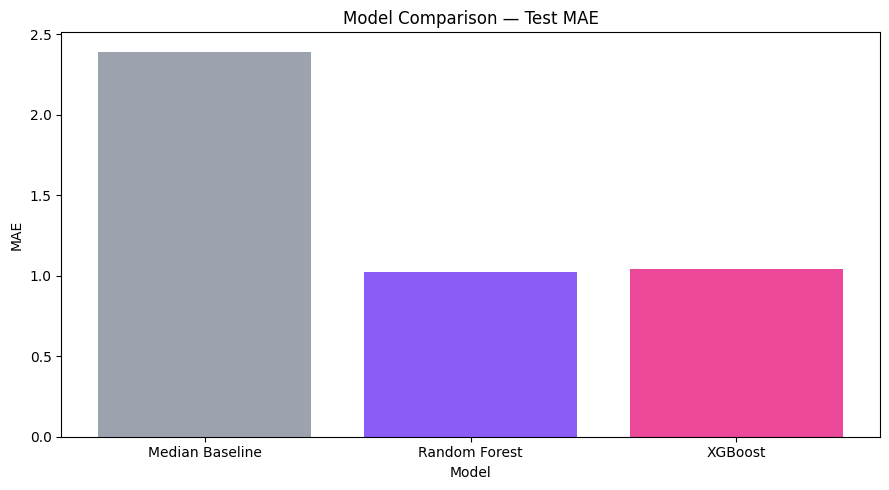

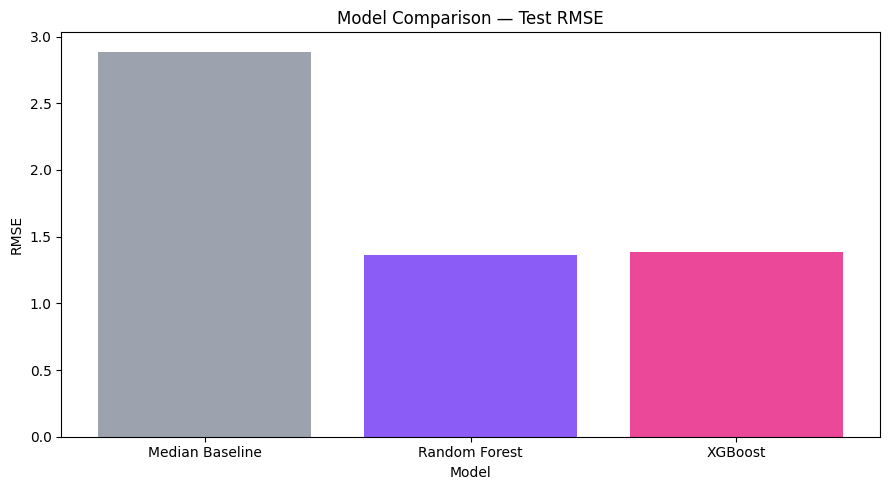

In [ ]:
# Results vs Baseline
# Compare all models on the same validation and untouched test splits.

import pandas as pd
import matplotlib.pyplot as plt

results_df = pd.DataFrame({
    "Model": ["Median Baseline", "Random Forest", "XGBoost"],
    "Validation MAE": [baseline_val_mae, rf_val_mae, xgb_val_mae],
    "Validation RMSE": [baseline_val_rmse, rf_val_rmse, xgb_val_rmse],
    "Test MAE": [baseline_test_mae, rf_test_mae, xgb_test_mae],
    "Test RMSE": [baseline_test_rmse, rf_test_rmse, xgb_test_rmse]
})

results_df["Test MAE Improvement (%)"] = (
    (baseline_test_mae - results_df["Test MAE"]) / baseline_test_mae * 100
)
results_df["Test RMSE Improvement (%)"] = (
    (baseline_test_rmse - results_df["Test RMSE"]) / baseline_test_rmse * 100
)

print("MODEL PERFORMANCE")
print("=" * 80)
display(results_df.round(4))

MODEL_COLORS = {
    "Median Baseline": "#9CA3AF",
    "Random Forest": "#8B5CF6",
    "XGBoost": "#EC4899"
}

plt.figure(figsize=(9, 5))
plt.bar(
    results_df["Model"],
    results_df["Test MAE"],
    color=[MODEL_COLORS[m] for m in results_df["Model"]]
)
plt.ylabel("MAE")
plt.xlabel("Model")
plt.title("Model Comparison — Test MAE")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.bar(
    results_df["Model"],
    results_df["Test RMSE"],
    color=[MODEL_COLORS[m] for m in results_df["Model"]]
)
plt.ylabel("RMSE")
plt.xlabel("Model")
plt.title("Model Comparison — Test RMSE")
plt.tight_layout()
plt.show()


## 5. Limitations

### 5. Limitations

This analysis is designed as a predictive prioritization system rather than a causal study of search performance.

1. **No causal interpretation.**  
   The dataset is observational, so the model can identify predictive relationships between current-month signals and next-month impressions but cannot establish that changing any individual signal will cause search performance to improve.

2. **The target is search demand, not Google ranking.**  
   The model estimates next-month Google Search impressions from current-month signals. It does not reproduce or prove Google's ranking algorithm, nor does it establish why a page gains or loses ranking.

3. **Temporal generalization is limited.**  
   The evaluation uses chronological train, validation, and test periods. The same clients may therefore appear across different periods. This reflects a future-period prediction setting, but it does not measure performance on completely unseen clients.

4. **Low-volume pages are harder to predict.**  
   Error analysis shows higher prediction error among pages with relatively low current-month impressions. Sparse search observations can make month-to-month demand changes less stable.

5. **Measurement availability changes over time.**  
   Google Analytics 4 data is not available consistently across the full warehouse period. GA4-derived signals are therefore interpreted only where the corresponding data is available, and their changing coverage limits direct comparisons across all months.

6. **Feature availability limits content interpretation.**  
   The warehouse does not provide direct semantic fields such as page text, content length, title/meta information, or explicit content type. Consequently, any archetype analysis in this project represents measurable performance patterns rather than semantic content categories.

7. **Feature importance is not causal importance.**  
   Random Forest feature importance describes how useful features were for the model's predictions. It should not be interpreted as evidence that changing a high-importance feature will directly improve future search performance. Some search signals, such as clicks, impressions, and CTR, are also mathematically related.

8. **Opportunity scores require human review.**  
   The opportunity score combines observable search-performance signals and model predictions to create a prioritization queue. It is a decision-support mechanism, not an automated recommendation that a page should definitely be changed.

These limitations define the appropriate scope of the findings: the system is useful for ranking observations for further investigation, while stronger claims about causality, semantic content quality, or search-engine behavior would require additional data and experimental validation.

## 6. Ranked Recommendations

The opportunity-scoring layer converts model predictions and observed search-performance signals into a ranked review queue. This section is the **action-playbook output** of the capstone.

The queue is intended to answer: **which observations should a content/SEO team review first, and what should they investigate?**

### 6.1 Ranking logic

Each observation receives an opportunity score based on:

- 30% current visibility
- 20% CTR opportunity
- 20% average-position opportunity
- 30% predicted next-month search demand

The queue is then sorted from highest to lowest opportunity score.

### 6.2 Priority tiers

The queue is divided into four equal-sized tiers using opportunity-score quartiles:

1. **Immediate Review** — highest-scoring observations
2. **High Priority** — strong opportunity signals
3. **Review** — moderate opportunity signals
4. **Monitor** — lower-priority observations for continued observation

These are **rank-based decision tiers**, not natural clusters and not probabilities of improvement.

### 6.3 Action playbook

- **Review search-result engagement:** investigate relatively low CTR and whether the page's search-result presentation warrants human review.
- **Review ranking/visibility opportunity:** investigate relatively higher average-position values alongside the other score components.
- **Review growth potential:** investigate observations with relatively high predicted next-month impressions.
- **Monitor performance:** continue observation where the combined opportunity score is lower.

### 6.4 Performance archetype context

The assigned performance archetype can be used as additional descriptive context when reviewing a ranked observation. It does **not** mean that the observation belongs to a known semantic content type, and it should not be treated as proof that one archetype is causally better than another.

### 6.5 Honest framing

The ranked recommendations identify **what to review first**, not what will definitely improve.

They do not:

- prove Google's ranking algorithm;
- identify causal SEO interventions;
- guarantee that refreshing a page will increase impressions;
- claim that a specific content archetype will perform better for a keyword.

The queue should therefore be used as a human-reviewed prioritization system.


In [ ]:
# Ranked Recommendations
# Fast vectorized version

# 1. Create priority tiers

opportunity_df["priority_tier"] = pd.qcut(
    opportunity_df["opportunity_score"],
    q=4,
    labels=[
        "Monitor",
        "Review",
        "High Priority",
        "Immediate Review"
    ]
)

# 2. Calculate medians once

median_ctr = opportunity_df["ctr"].median()
median_position = opportunity_df["avg_position"].median()
median_predicted = opportunity_df["predicted_impressions"].median()

# 3. Assign actions without row-by-row apply

opportunity_df["recommended_action"] = np.select(
    [
        opportunity_df["ctr"] < median_ctr,
        opportunity_df["avg_position"] > median_position,
        opportunity_df["predicted_impressions"] > median_predicted
    ],
    [
        "Review search-result engagement",
        "Review ranking/visibility opportunity",
        "Review growth potential"
    ],
    default="Monitor performance"
)

# 4. Create final ranked queue

ranked_recommendations = opportunity_df[
    [
        "priority_rank",
        "priority_tier",
        "archetype",
        "impressions",
        "clicks",
        "ctr",
        "avg_position",
        "predicted_impressions",
        "opportunity_score",
        "recommended_action"
    ]
].copy()

ranked_recommendations = ranked_recommendations.sort_values(
    "priority_rank"
)

print("RANKED CONTENT OPPORTUNITY QUEUE")
print("=" * 80)

display(
    ranked_recommendations.head(25).round(4)
)

RANKED CONTENT OPPORTUNITY QUEUE


,priority_rank,priority_tier,archetype,impressions,clicks,ctr,avg_position,predicted_impressions,opportunity_score,recommended_action
0,1,Immediate Review,Performance Archetype 2,8822.0,0.0,0.0,70.7592,5183.124023,0.9059,Review ranking/visibility opportunity
1,2,Immediate Review,Performance Archetype 2,6249.0,0.0,0.0,50.9502,9623.146484,0.8992,Review ranking/visibility opportunity
2,3,Immediate Review,Performance Archetype 2,11874.0,0.0,0.0,50.7344,5133.507812,0.8979,Review ranking/visibility opportunity
3,4,Immediate Review,Performance Archetype 2,11669.0,0.0,0.0,48.2929,4837.106445,0.8948,Review ranking/visibility opportunity
4,5,Immediate Review,Performance Archetype 2,9974.0,0.0,0.0,46.9446,5544.081055,0.8945,Review ranking/visibility opportunity
5,6,Immediate Review,Performance Archetype 2,9661.0,0.0,0.0,47.0066,5290.753906,0.8936,Review ranking/visibility opportunity
6,7,Immediate Review,Performance Archetype 2,7394.0,0.0,0.0,49.9366,5480.430176,0.8934,Review ranking/visibility opportunity
7,8,Immediate Review,Performance Archetype 2,6105.0,0.0,0.0,50.2501,5584.337402,0.8914,Review ranking/visibility opportunity
8,9,Immediate Review,Performance Archetype 2,8776.0,0.0,0.0,40.7023,7180.831055,0.8913,Review ranking/visibility opportunity
9,10,Immediate Review,Performance Archetype 2,8859.0,0.0,0.0,40.4756,7180.831055,0.8912,Review ranking/visibility opportunity


In [ ]:
# Summary of the recommendation queue by priority tier.

tier_summary = (
    ranked_recommendations
    .groupby("priority_tier", observed=False)
    .agg(
        opportunities=("priority_rank", "size"),
        median_score=("opportunity_score", "median"),
        median_impressions=("impressions", "median"),
        median_ctr=("ctr", "median"),
        median_position=("avg_position", "median")
    )
    .reset_index()
)

print("OPPORTUNITY TIER SUMMARY")
print("=" * 70)

display(tier_summary.round(4))

OPPORTUNITY TIER SUMMARY


,priority_tier,opportunities,median_score,median_impressions,median_ctr,median_position
0,Monitor,108159,0.2569,3.0,0.0000,5.0000
1,Review,108158,0.4660,37.0,0.0000,14.6222
2,High Priority,108158,0.5841,250.0,0.0000,13.8721
3,Immediate Review,108159,0.6818,1485.0,0.0007,17.0746


### 6.6 Generated recommendation artifacts

The code below generates the final ranked queue and tier summary from the current notebook run. The deployed paper should use the values produced by this final run rather than hard-coded values.


## 7. Artifacts the paper embeds



The research paper will embed or reference the following reproducible artifacts from this capstone:

1. **Research question and scope**
   - Defines the prediction task, unit of analysis, and intended use of the output.
   - Establishes that the system is a predictive prioritization tool rather than a causal model of Google Search.

2. **Data and feature pipeline**
   - Documents the monthly aggregation of Google Search Console and available Google Analytics 4 signals.
   - Uses client and content identifiers only for grouping and temporal joins.
   - Excludes the final month from modeling because a subsequent month is required to construct the target.

3. **Temporal modeling setup**
   - Training period: January–December 2025.
   - Validation period: January–March 2026.
   - Test period: April–May 2026.
   - June 2026 is excluded because a subsequent month is unavailable for target construction.

4. **Model comparison**
   - Median baseline, Random Forest, and XGBoost are evaluated on the same held-out test period.
   - The final model is selected using validation performance; the untouched test period is reserved for final held-out comparison.

5. **Model explainability**
   - Feature importance and SHAP for the validation-selected final model are used to describe global and observation-level predictive behavior.
   - SHAP values are calculated on a fixed sample of the held-out test set for computational practicality.
   - Both forms of explanation are interpreted descriptively rather than causally.

6. **Performance archetype clustering**
   - MiniBatchKMeans groups observations using scaled, measurable search-performance and engagement features.
   - The number of clusters is selected using silhouette score on a reproducible training-data sample.
   - Cluster profiles are reported as performance archetypes rather than semantic content categories.

7. **Error analysis**
   - Prediction errors are examined across current-month impression-volume bands.
   - The analysis shows that lower-volume observations have larger prediction errors than higher-volume observations.

8. **Opportunity scoring**
   - Model predictions and current search-performance signals are combined into a normalized opportunity score.
   - Observations are placed into four priority tiers for human review.

8. **Ranked recommendation queue**
   - Produces a reproducible, ranked review queue without exposing client names, domains, URLs, private queries, or raw warehouse exports.

9. **Reproducibility**
   - The notebook contains the data preparation, modeling, evaluation, explainability, error analysis, and opportunity-scoring workflow required to reproduce the analysis within the approved FlyRank environment.

All findings are subject to the limitations described in Section 5. The final paper will distinguish predictive associations from causal claims and will not claim to reproduce or prove Google's ranking algorithm.

### Final paper-only sections

The deployed research paper will add the **5-sentence Abstract** at the top and **Acknowledgments & Data Credit** at the bottom after the notebook analysis is finalized. These are paper sections rather than additional modeling cells.


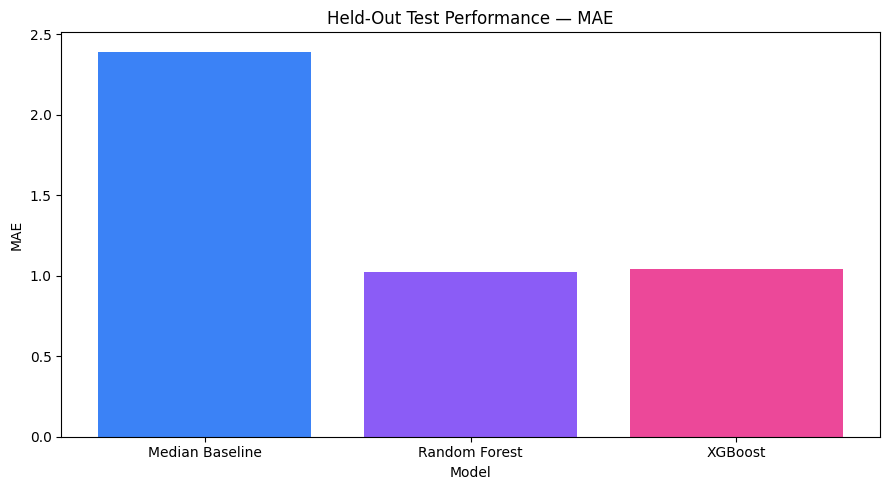

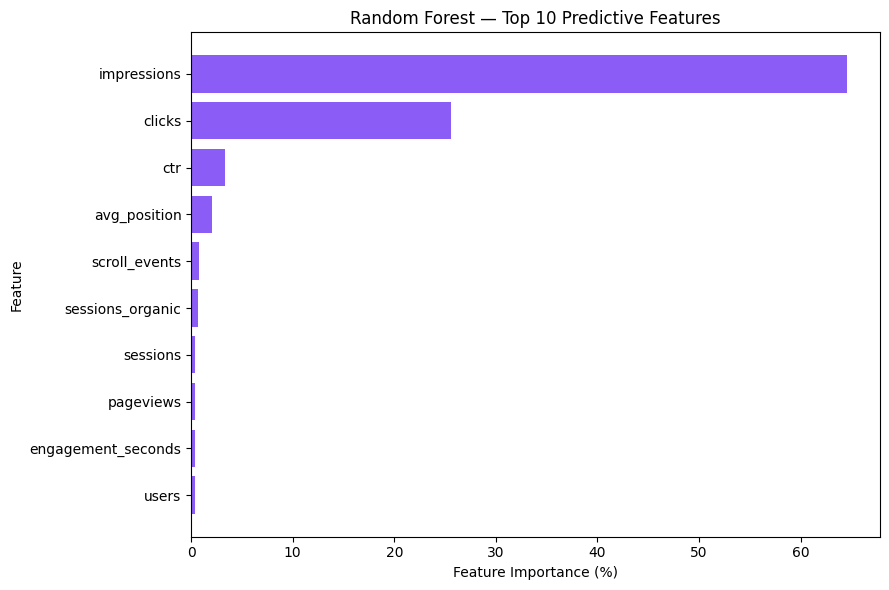

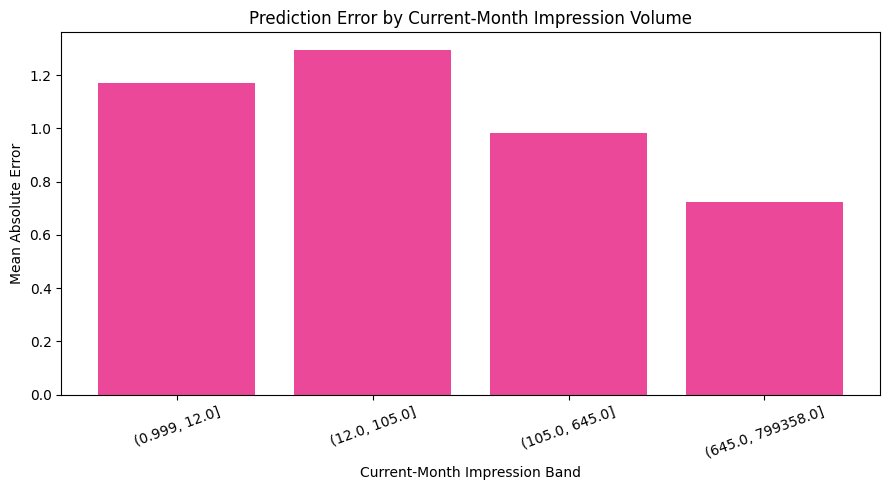

In [ ]:
# Paper-Ready Visual Artifacts

import matplotlib.pyplot as plt

# Consistent colors across the paper
MODEL_COLORS = {
    "Baseline": "#9CA3AF",
    "Random Forest": "#8B5CF6",
    "XGBoost": "#EC4899"
}


# ============================================================
# CHART 1 — Model Performance (MAE)
# ============================================================

plt.figure(figsize=(9, 5))

colors = [
    MODEL_COLORS.get(model, "#3B82F6")
    for model in results_df["Model"]
]

plt.bar(
    results_df["Model"],
    results_df["Test MAE"],
    color=colors
)

plt.ylabel("MAE")
plt.xlabel("Model")
plt.title("Held-Out Test Performance — MAE")

plt.tight_layout()
plt.show()


# ============================================================
# CHART 2 — Random Forest Feature Importance
# ============================================================

top_features = (
    final_importance
    .head(10)
    .sort_values("importance_pct")
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["feature"],
    top_features["importance_pct"],
    color="#8B5CF6"
)

plt.xlabel("Feature Importance (%)")
plt.ylabel("Feature")
plt.title("Random Forest — Top 10 Predictive Features")

plt.tight_layout()
plt.show()


# ============================================================
# CHART 3 — Error by Impression Volume
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    error_by_band["impression_band"].astype(str),
    error_by_band["mean_absolute_error"],
    color="#EC4899"
)

plt.xlabel("Current-Month Impression Band")
plt.ylabel("Mean Absolute Error")
plt.title("Prediction Error by Current-Month Impression Volume")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

## ML-12 — Closing Communication Artifacts

### 5-Minute Demo Outline

**0:00–0:30 — Problem**  
Explain the decision problem: identify content observations that deserve human review based on current search-performance signals and expected next-month search demand.

**0:30–1:15 — Data**  
Show the monthly client/content aggregation, available GSC and GA4-derived signals, and the chronological train/validation/test design.

**1:15–2:15 — Modeling**  
Show the median baseline, Random Forest, and XGBoost comparison. Explain that the target is `log1p(next_impressions)`.

**2:15–3:00 — Explainability and validation**  
Show the selected model's feature importance, SHAP global contributions, and the error analysis by impression volume.

**3:00–4:00 — Archetypes and opportunity scoring**  
Show the performance-archetype clustering, cluster profiles, opportunity score, and ranked review queue.

**4:00–5:00 — Recommendations and limitations**  
Explain the review actions, then state clearly that the system is predictive decision support, not a causal model of Google Search or a guarantee that an intervention will improve performance.

### Social-Post Cut

Built an ML-based search-performance opportunity system during my FlyRank AI Machine Learning Engineering internship. I used a temporal modeling setup to predict next-month search impressions, compared Random Forest and XGBoost against a median baseline, added SHAP explainability and performance-archetype clustering, and converted the outputs into a ranked review queue. The main lesson was that strong predictive performance can support prioritization, but it does not by itself establish causality or guarantee that a content change will improve search performance.

### Employer-Facing Summary

I built a temporal ML pipeline that predicts next-month search impressions from current search and engagement signals and compared tree-based models against a baseline. I added SHAP explainability, performance-archetype clustering, error analysis, and an opportunity-scoring layer to turn model output into a human-review queue. The project demonstrates practical work across data preparation, temporal validation, supervised and unsupervised ML, model interpretation, and decision-support design.


## 8. Research Paper Deliverable Map

The notebook is the reproducible research artifact behind the deployed public paper. The deployed paper must contain these sections in this order:

1. **Title + 5-sentence Abstract**
2. **Introduction / Problem Statement** — the decision this work supports
3. **Data** — release, table, date window, included signals, exclusions, and public-safe framing
4. **Methodology** — assumptions, features, target/label, baseline, Random Forest vs XGBoost comparison, temporal validation, leakage checks, SHAP, clustering, and opportunity scoring
5. **Results** — model vs baseline on the same held-out test split, charts, SHAP, clustering/error-analysis evidence
6. **Limitations & Honest Framing**
7. **Ranked Recommendations** — the action playbook generated in Section 6
8. **Reproducibility** — links to the notebooks and repository
9. **Acknowledgments & Data Credit** — includes the exact wording: **“Built on the FlyRank ML Internship dataset”** and is linked to `https://flyrank.ai` in the deployed paper.

### Submission repository requirements

The repository contains:

- all assignment notebooks under `work/`;
- this capstone notebook under `work/notebooks/`;
- `submission/paper_url.txt` containing **exactly one line**: the direct URL of the deployed public research paper.

### Acknowledgments & data credit

Use the exact credit in the deployed paper:

**Built on the FlyRank ML Internship dataset**

The credit should link to `https://flyrank.ai` and open in a new tab.

### Public-safe rule

The deployed paper and repository must follow the public rule: no client names, domains, private queries, credentials, raw exports, claims that prove Google's algorithm, or causal refresh-impact claims.


## Self-check

Before submission, confirm each item honestly:

- [x] Run the notebook top-to-bottom in the final runtime and resolve every error.
- [x] Section 3 explicitly documents Random Forest, XGBoost comparison, SHAP explainability, temporal validation, leakage controls, performance archetype clustering, error analysis, and opportunity scoring.
- [x] Ranked recommendations are Section 6, not part of Section 3 methodology.
- [x] No client names, private queries, credentials, or raw warehouse exports are included.
- [x] Unavailable fields from the original plan are not fabricated.
- [x] Claims use observed, predictive, directional, or decision-support language.
- [x] Model selection is based on validation performance; the test period remains held out for final comparison.
- [x] The deployed paper must contain all required sections, including the 5-sentence Abstract and Acknowledgments & data credit.
- [x] The repository must contain `work/` notebooks and `submission/paper_url.txt` with exactly one direct paper URL.
- [x] ML-12 closing communication artifacts are included.
